In [13]:
import numpy as np
import torch
from IPython.display import display, Math
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Matrix and Matmul

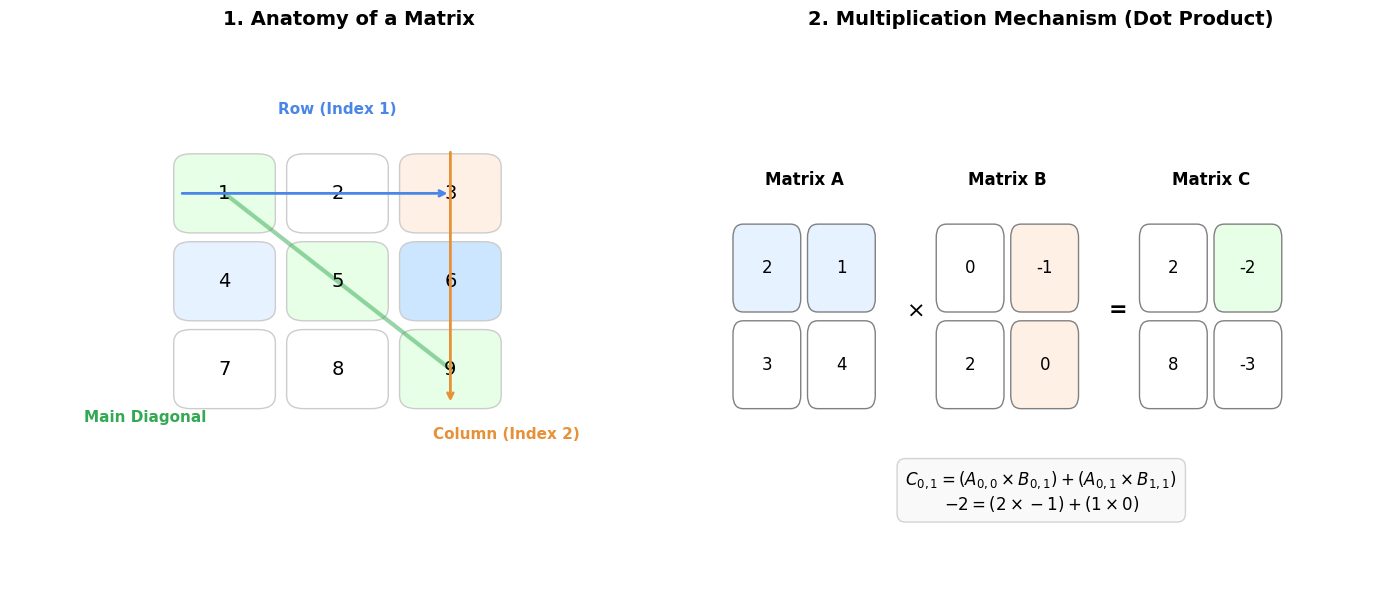

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.set_xlim(0, 6)
ax1.set_ylim(0, 6)
ax1.axis('off')
ax1.set_title("1. Anatomy of a Matrix", fontsize=14, fontweight='bold', pad=20)

matrix_vals = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]

for i in range(3):
    for j in range(3):
        x = 1.5 + j
        y = 4 - i
        
        facecolor = 'white'
        if i == 1:
            facecolor = '#e6f2ff' 
        if j == 2: 
            if facecolor == '#e6f2ff':
                facecolor = '#cce6ff'
            else:
                facecolor = '#fff0e6'
        if i == j: 
            facecolor = '#e6ffe6'

        rect = patches.FancyBboxPatch(
            (x, y), 0.8, 0.8, 
            boxstyle="round,pad=0.05,rounding_size=0.15", 
            linewidth=1, edgecolor='#cccccc', facecolor=facecolor
        )
        ax1.add_patch(rect)
        ax1.text(x + 0.4, y + 0.4, str(matrix_vals[i][j]), fontsize=14, ha='center', va='center')

ax1.text(2.9, 5.3, "Row (Index 1)", color='#4A86E8', fontsize=11, ha='center', fontweight='bold')
ax1.annotate('', xy=(3.9, 4.4), xytext=(1.5, 4.4), arrowprops=dict(arrowstyle="->", color='#4A86E8', lw=2))

ax1.text(4.4, 1.6, "Column (Index 2)", color='#E69138', fontsize=11, ha='center', fontweight='bold')
ax1.annotate('', xy=(3.9, 2.0), xytext=(3.9, 4.9), arrowprops=dict(arrowstyle="->", color='#E69138', lw=2))

ax1.text(1.2, 1.8, "Main Diagonal", color='#34A853', fontsize=11, ha='center', fontweight='bold')
ax1.plot([1.9, 3.9], [4.4, 2.4], color='#34A853', lw=3, alpha=0.5)


ax2.set_xlim(0, 10)
ax2.set_ylim(0, 6)
ax2.axis('off')
ax2.set_title("2. Multiplication Mechanism (Dot Product)", fontsize=14, fontweight='bold', pad=20)

def draw_2x2(ax, x_offset, y_offset, vals, title, highlight_row=None, highlight_col=None, result_cell=None):
    ax.text(x_offset + 1, y_offset + 2.5, title, fontsize=12, fontweight='bold', ha='center')
    for i in range(2):
        for j in range(2):
            x = x_offset + j * 1.1
            y = y_offset + (1 - i) * 1.1
            
            fc = 'white'
            if highlight_row == i: fc = '#e6f2ff'
            if highlight_col == j: fc = '#fff0e6'
            if result_cell == (i, j): fc = '#e6ffe6'
            
            # FIX: Sama di sini juga diganti pakai FancyBboxPatch
            rect = patches.FancyBboxPatch(
                (x, y), 0.9, 0.9, 
                boxstyle="round,pad=0.05,rounding_size=0.15", 
                linewidth=1, edgecolor='gray', facecolor=fc
            )
            ax.add_patch(rect)
            ax.text(x + 0.45, y + 0.45, str(vals[i][j]), fontsize=12, ha='center', va='center')

draw_2x2(ax2, 0.5, 2, [[2, 1], [3, 4]], "Matrix A", highlight_row=0)
ax2.text(3.0, 3.0, r"$\times$", fontsize=16, fontweight='bold')

draw_2x2(ax2, 3.5, 2, [[0, -1], [2, 0]], "Matrix B", highlight_col=1)
ax2.text(6.0, 3.0, "=", fontsize=16, fontweight='bold')

draw_2x2(ax2, 6.5, 2, [[2, -2], [8, -3]], "Matrix C", result_cell=(0, 1))

formula_text = (
    r"$C_{0,1} = (A_{0,0} \times B_{0,1}) + (A_{0,1} \times B_{1,1})$" + "\n" + 
    r"$-2 = (2 \times -1) + (1 \times 0)$"
)
ax2.text(5.0, 0.8, formula_text, fontsize=12, ha='center', 
         bbox=dict(facecolor='#f9f9f9', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

- Formula dot product: $C[i][j] = \Sigma A[i][k] @ B[k][j]$ - row i from A * cols j from B
    - (required) `col A = row B`, so (mxn)@(nxp) = (mxp) 

# Transformation

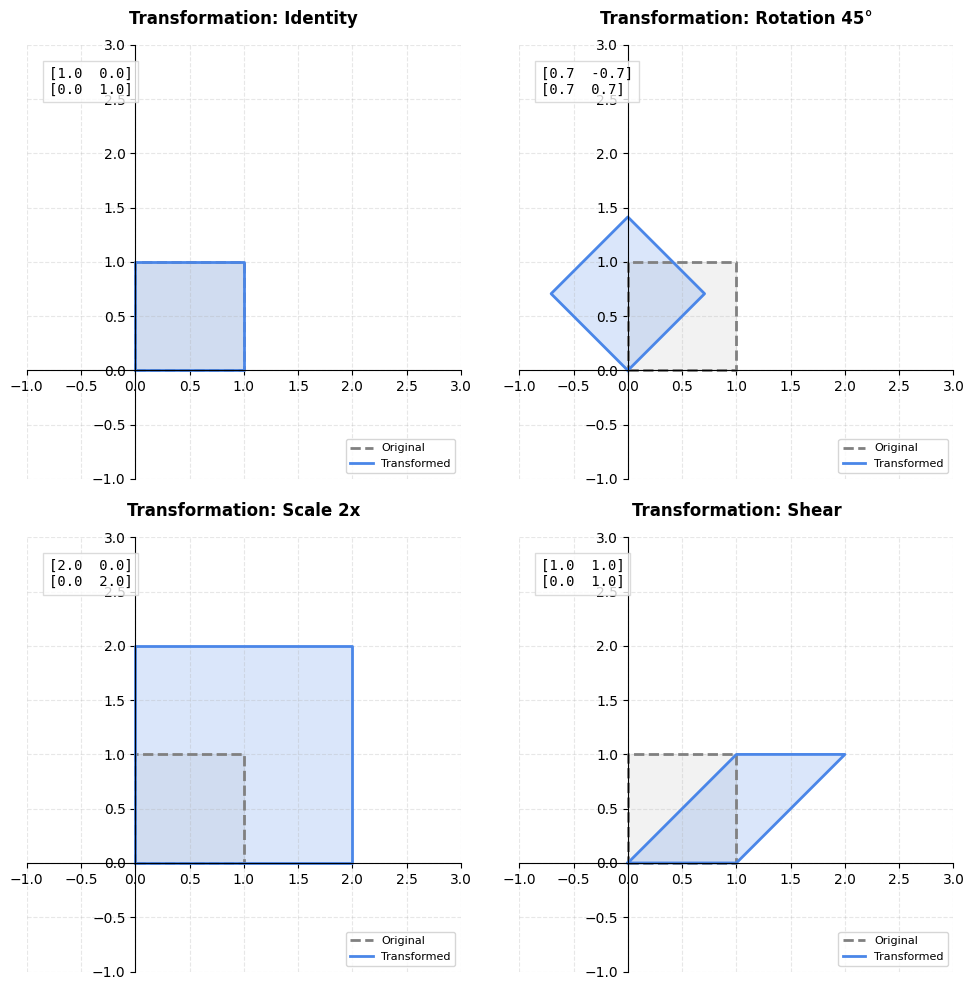

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()

matrices = {
    "Identity": np.array([[1, 0], [0, 1]]),
    "Rotation 45°": np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)], [np.sin(np.pi/4), np.cos(np.pi/4)]]),
    "Scale 2x": np.array([[2, 0], [0, 2]]),
    "Shear": np.array([[1, 1], [0, 1]])
}

square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])

for i, (title, mat) in enumerate(matrices.items()):
    ax = axs[i]
    
    transformed_square = np.dot(square, mat.T)
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.set_xlim(-1, 3)
    ax.set_ylim(-1, 3)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    ax.plot(square[:, 0], square[:, 1], linestyle='--', color='gray', label='Original', lw=2)
    ax.fill(square[:, 0], square[:, 1], color='gray', alpha=0.1)
    
    ax.plot(transformed_square[:, 0], transformed_square[:, 1], color='#4A86E8', label='Transformed', lw=2)
    ax.fill(transformed_square[:, 0], transformed_square[:, 1], color='#4A86E8', alpha=0.2)
    
    mat_str = f"[{mat[0,0]:.1f}  {mat[0,1]:.1f}]\n[{mat[1,0]:.1f}  {mat[1,1]:.1f}]"
    ax.text(0.05, 0.95, mat_str, transform=ax.transAxes, fontsize=10, fontfamily='monospace',
            va='top', bbox=dict(facecolor='white', edgecolor='lightgray', alpha=0.8))
    
    ax.set_title(f"Transformation: {title}", fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

- Identity: it unchange anything, In neural nets is like skip connection schema
- Rotate $45^\degree$: rotate all points by $45^\degree$ relative to the origin. The magnitude remain unchanged but the direction change
- Scale 2x: X axis enlarged 2x
- Shear: tilt the space, Y axis unchanged but X axis shifted by the Y axis. This is how the network "blends" different dimensions.


# Transpose & Invers

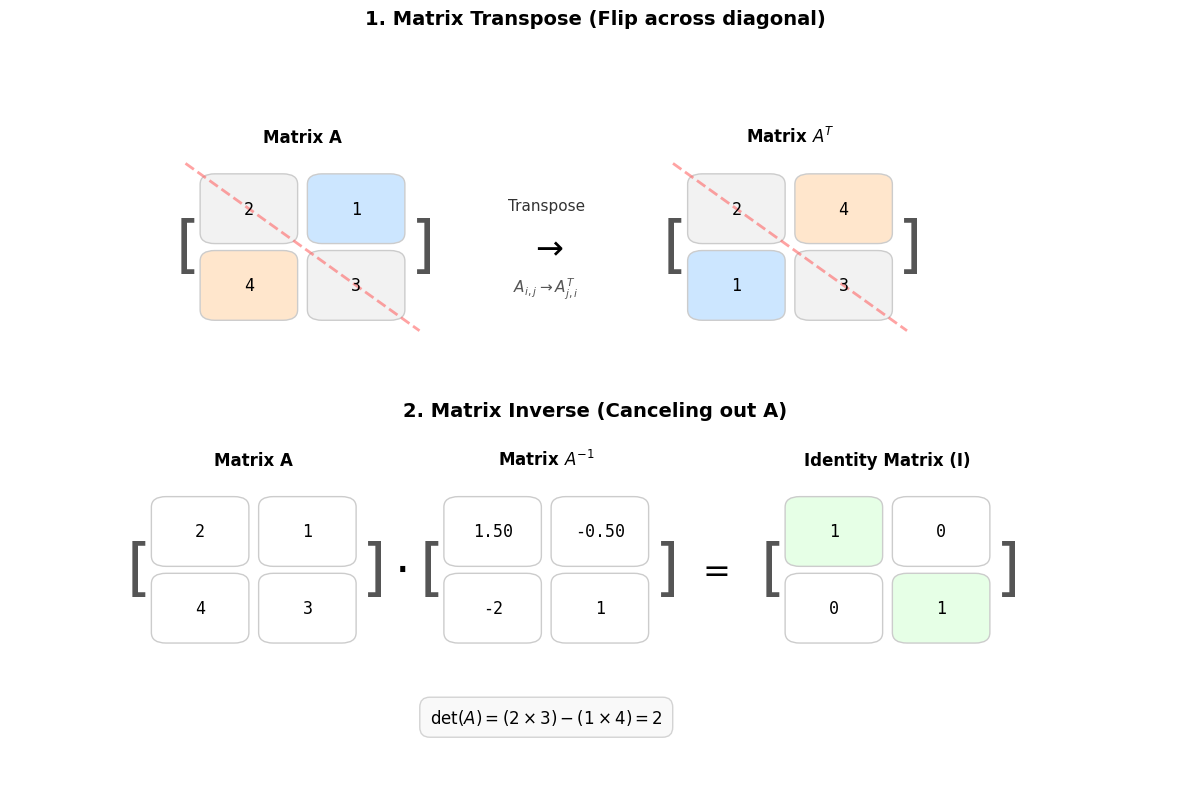

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.set_xlim(0, 12)
ax1.set_ylim(0, 5)
ax1.axis('off')
ax1.set_title("1. Matrix Transpose (Flip across diagonal)", fontsize=14, fontweight='bold', pad=10)

def draw_matrix(ax, x0, y0, mat, title, cmap=None):
    ax.text(x0 + 1, y0 + 2.5, title, ha='center', fontsize=12, fontweight='bold')
    ax.text(x0 - 0.1, y0 + 1, r"$[$", fontsize=45, ha='right', va='center', color='#555555')
    ax.text(x0 + 2.1, y0 + 1, r"$]$", fontsize=45, ha='left', va='center', color='#555555')
    
    for i in range(2):
        for j in range(2):
            val = mat[i][j]
            x = x0 + j * 1.1
            y = y0 + (1 - i) * 1.1
            c = cmap.get((i, j), 'white') if cmap else 'white'
            
            rect = patches.FancyBboxPatch(
                (x, y), 0.9, 0.9,
                boxstyle="round,pad=0.05,rounding_size=0.15",
                linewidth=1, edgecolor='#cccccc', facecolor=c
            )
            ax.add_patch(rect)
            
            val_str = f"{val:g}" if val == int(val) else f"{val:.2f}"
            ax.text(x + 0.45, y + 0.45, val_str, ha='center', va='center', fontsize=12, fontfamily='monospace')

cmap_A = {(0,0): '#f2f2f2', (1,1): '#f2f2f2', (0,1): '#cce6ff', (1,0): '#ffe6cc'}
draw_matrix(ax1, 2, 1, [[2, 1], [4, 3]], "Matrix A", cmap_A)

ax1.text(5.5, 2, r"$\rightarrow$", fontsize=24, ha='center', va='center')
ax1.text(5.5, 2.6, "Transpose", ha='center', va='center', fontsize=11, color='#333333')
ax1.text(5.5, 1.4, r"$A_{i,j} \rightarrow A^T_{j,i}$", ha='center', va='center', fontsize=11, color='#555555')

cmap_AT = {(0,0): '#f2f2f2', (1,1): '#f2f2f2', (0,1): '#ffe6cc', (1,0): '#cce6ff'}
draw_matrix(ax1, 7, 1, [[2, 4], [1, 3]], r"Matrix $A^T$", cmap_AT)

ax1.plot([1.8, 4.2], [3.2, 0.8], color='#ff6666', linestyle='--', alpha=0.6, lw=2)
ax1.plot([6.8, 9.2], [3.2, 0.8], color='#ff6666', linestyle='--', alpha=0.6, lw=2)


ax2.set_xlim(0, 12)
ax2.set_ylim(-1, 4)
ax2.axis('off')
ax2.set_title("2. Matrix Inverse (Canceling out A)", fontsize=14, fontweight='bold', pad=10)

draw_matrix(ax2, 1.5, 1, [[2, 1], [4, 3]], "Matrix A")
ax2.text(4.0, 2, r"$\cdot$", fontsize=35, ha='center', va='center')

draw_matrix(ax2, 4.5, 1, [[1.5, -0.5], [-2.0, 1.0]], r"Matrix $A^{-1}$")
ax2.text(7.2, 2, r"$=$", fontsize=24, ha='center', va='center')

cmap_I = {(0,0): '#e6ffe6', (1,1): '#e6ffe6'}
draw_matrix(ax2, 8.0, 1, [[1, 0], [0, 1]], "Identity Matrix (I)", cmap_I)

ax2.text(5.5, -0.2, r"$\det(A) = (2 \times 3) - (1 \times 4) = 2$", ha='center', fontsize=12, 
         bbox=dict(facecolor='#f9f9f9', edgecolor='lightgray', boxstyle='round,pad=0.6'))

plt.tight_layout()
plt.show()

- Transpose as simple reverse rows to cols and vice versa
    - $A[i][j] => A^T = A[j][i]$
    - if we have $(AB)^T$ = $B^TA^T$ (reversed order)
- Inverse $A^-1$ means "undo" efek so $A@A^-1 = I$(identity)
    - (require) det(A) ≠ 0. If det=0, matrix singular haven't inverse

In [19]:
A = torch.tensor(
    [[2,1,5],
    [4,3,8]]
,dtype=torch.float)

print(A)
print(f'➡️ A shape: {A.shape}\n')
print(A.T)
print(f'➡️ A Transpose shape: {A.T.shape}')

tensor([[2., 1., 5.],
        [4., 3., 8.]])
➡️ A shape: torch.Size([2, 3])

tensor([[2., 4.],
        [1., 3.],
        [5., 8.]])
➡️ A Transpose shape: torch.Size([3, 2])


## just insight ✨

- Why matmul is important? cuz nowadays in AI, 1 layer of neur nets is matmul: out = Wx+b. If we have 1000 layer means 1000 times matmul consecutive and some times u just realize training GPT, Gemini etc with bilion params is about find right matrix W in each layer. Now all calculated paralel in GPU (so that jensen huang RICH wkwk)
- In attention mechanism formula: $softmax(\frac{QK^T}{\sqrt{d_k}}) V$ contains 2 matmul
    - $QK^T$ for calculated similarity of each token
    - the result multiple by V for information aggregation

In [22]:
# attention mech idea
d_k = 64
Q = torch.randn(10,d_k)
print(Q.shape)
K = torch.randn(10,d_k)
print(K.shape)
V = torch.randn(10,d_k)
print(V.shape)

scores = Q@K.T / d_k**0.5
print(scores.shape) # cuz (10,64)*(64,10) = (10,10)
weights = torch.softmax(scores,dim=-1)
print(weights.shape) # softmax unchanged anything
out = weights@V
print(out.shape)

torch.Size([10, 64])
torch.Size([10, 64])
torch.Size([10, 64])
torch.Size([10, 10])
torch.Size([10, 10])
torch.Size([10, 64])
